**Task 1 - the Lorenz system.** The Lorenz system in an autonomous first order system of differential equations 
\begin{align*}
    \dot{x} &= \sigma (y - x) \textrm{, }\\
    \dot{y} &= x (\rho - z) - y \textrm{, }\\
    \dot{z} &= xy - \beta z \textrm{. }
\end{align*}
Here $\sigma, \rho, \beta > 0$ (the actual values that Lorenz used are $\sigma = 10$, $\rho = 28$ and $\beta = \frac{8}{3}$). This system is deterministic, but it exhibits chaotic behavior.

- Use RK4 to simulate this system for a few (nearby) initial conditions. Create an animation to better visualize the time dependence.
- Find the stationary points of the Lorenz system. How do the solutions behave in the vicinity of those stationary points?

Having seen a few solutions, it should seem plausible that there are also periodic solutions to the Lorenz system. (In fact, there are many.) Let's try and find at least one periodic solution.

Assume that we have a half-plane $P \subseteq \mathbb{R}^3$ and a vector $\mathbf{x}_0 = [x_0, y_0, z_0]^\mathsf{T} \in P$. Denote by $\mathbf{x}(t)$ the solution of the Lorenz system with initial condition $\mathbf{x}(t_0) = \mathbf{x}_0$. Additionally assume that, for some $T > 0$, we have $\mathbf{x}(t_0 + T) \in P$ and that $\dot{\mathbf{x}}(t_0)$ and $\dot{\mathbf{x}}(t_0+T)$ point in the same half-space with respect to $P$. (Both assumptions are valid for the Lorenz system.) This describes a map $$\mathbf{p} \colon P \to P, \mathbf{x}_0 \mapsto \mathbf{x}(t_0 + T) \textrm{, }$$ usually called _the first return map_ or _the Poincare map_ (of the Lorenz system wrt. $P$). Fixed points of the Poincare map (i.e., $\mathbf{x}_0 \in P$ such that $\mathbf{p}(\mathbf{x}_0) = \mathbf{x}_0$) describe periodic orbits, since then $\mathbf{x}(t_0 + T) = \mathbf{x}(t_0)$.

- Pick an appropriate (at least seemingly appropriate) half-plane $P \subseteq \mathbb{R}^3$ and write a _Julia_ function which evaluates the first return map $\mathbf{p}$ for the Lorenz system (wrt. $P$). 
- Solve the equation $\mathbf{p}(\mathbf{x}) = \mathbf{x}$. Use Newton's method.
- Watch the 'periodic' orbit evolve by simulating the Lorenz system with the obtained initial condition over a longer period of time. 

Note that you'll need a 'very good' initial approximation for the Newton's method due to chaotic behavior of the Lorenz system.

In [1]:
# We'll need (code from ) `rk4` and `newton`. Both included for convenience.

function rk4(f, Y0, (t0, tk), h)
    # set time steps
    t = t0:h:tk
    # initial Y value
    Y = [Y0]
    for ti in t[1:end-1]
        k1 = h*f(ti, Y[end])
        k2 = h*f(ti+h/2, Y[end]+k1/2)
        k3 = h*f(ti+h/2, Y[end]+k2/2)
        k4 = h*f(ti+h, Y[end]+k3)
        # add the next approximation to Y
        push!(Y, Y[end] + (k1 + 2*k2 + 2*k3 + k4)/6)
    end

    return (t, Y)
end

using LinearAlgebra
# the actual `newton` function
"""
    newton(F, JF, X0; kwargs...)

Find one solution of F(X)=0 for a vector-valued function `F` with Jacobian matrix `JF` using Newton's iteration with initial approximation `X0`. Returns a named tuple (X = X, n = n).

Keyword arguments are `tol = 1e-8` and `maxit = 100`.

# Examples
```julia-repl
julia> newton(x -> x^2 - 2, x -> 2x, 1.4).X
1.4142135623730951
```
"""
function newton(F, JF, X0; tol = 1e-8, maxit = 100)
    # set two variables which will be used (also) outside the for loop
    X = X0
    n = 1
    # first evaluation of F
    Y = F(X)
    for outer n = 1:maxit
        # execute one step of Newton's iteration
        X = X0 - JF(X0)\Y
        Y = F(X)
        # check if the result is within prescribed tolerance
        if norm(X-X0) + norm(Y) < tol
            break;
        end
        # otherwise repeat
        X0 = X
    end

    # a warning if maxit was reached
    if n == maxit
        @warn "no convergence after $maxit iterations"
    end
    # let's return a named tuple
    return (X = X, n = n)
end

newton

[ Info: Saved animation to /home/boobsson/Desktop/3. letnik FRI/MM/tmp.gif


Plots.AnimatedGif("/home/boobsson/Desktop/3. letnik FRI/MM/tmp.gif")
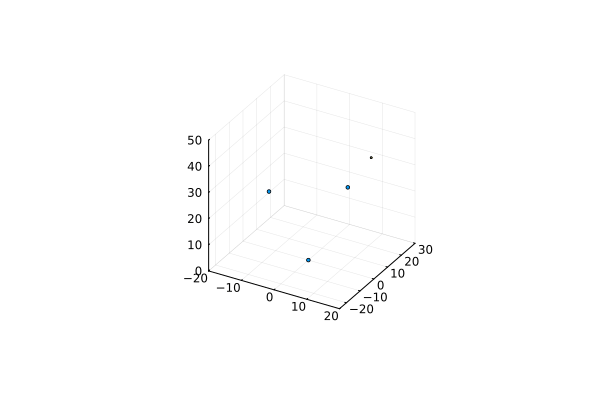

In [2]:
# constants of the Lorenz system
σ, ρ, β = 10, 28, 8/3
# the right-hand side function
F(t, Y) = [σ*(Y[2]-Y[1]); Y[1]*(ρ-Y[3])-Y[2]; Y[1]*Y[2]-β*Y[3]]
# an initial approximation
X0 = [15.; 10.; 40.]
# solution with the original initial condition
###
### YOUR CODE HERE
_, Y1 = rk4(F, X0, (0., 20.), 0.005)
_, Y2 = rk4(F, X0+ [0;0;0.01], (0., 20.), 0.005)

# and a solution with slightly modified initial condition
###
### YOUR CODE HERE
###
# stationary points of the Lorenz system
T1, T2, T3 = (0., 0., 0.), (sqrt(β*(ρ-1)), sqrt(β*(ρ-1)), ρ-1), (-sqrt(β*(ρ-1)), -sqrt(β*(ρ-1)), ρ-1)
# indices for the plot (to plot various projections of the phase diagram)
idx = [1, 2, 3]
using Plots
anim = @animate for k in eachindex(Y1)[1:10:end]
    # plot the stationary points
    scatter([T1[idx], T2[idx], T3[idx]]; markersize = 2, label = false)
    # plot of both trajectories
    plot!([Tuple(y) for y in Y1[maximum([1, k-200]):k]]; ratio = 1, xlims = (-20, 20), ylims = (-25, 30), zlims = (0, 50), label = false)
    scatter!(Tuple(Y1[k]); markersize = 1, label = false)
    plot!([Tuple(y) for y in Y2[maximum([1, k-200]):k]]; ratio = 1, xlims = (-20, 20), ylims = (-25, 30), zlims = (0, 50), label = false)
    scatter!(Tuple(Y2[k]); markersize = 1, label = false)
end
gif(anim; fps=20)

In [3]:
JF(Y) = [-σ σ 0;ρ-Y[3] -1 -Y[1]; Y[2] Y[1] -β]
eigenvalues2 = eigen(JF(collect(T3))).values

3-element Vector{ComplexF64}:
 -13.854577914596042 + 0.0im
 0.09395562396468593 - 10.19450522092785im
 0.09395562396468593 + 10.19450522092785im

In [4]:
# first return map for the Lorenz system for the half-plane P: y = √(β(ρ-1)), x > √(β(ρ-1))
# (actually a n-th return map - by modifying the kwarg retn)
function poincare(X0; σ = 10, ρ = 28, β = 8/3, h = 0.01, k0 = 20, tlimit = 200, retn = 1)
    # the right-hand side function of the Lorenz system
    F(Y) = [σ*(Y[2]-Y[1]); Y[1]*(ρ-Y[3])-Y[2]; Y[1]*Y[2]-β*Y[3]]
    # We start with an initial condition [x0; sqrt(β*(ρ-1); z0] on the plane y = sqrt(β*(ρ-1)).
    # (Here, X0 = [x0; z0].)
    Y = [[X0[1]; sqrt(β*(ρ-1)); X0[2]]]
    # Start RK4 and keep solving until the plane y = sqrt(β*(ρ-1)) is intersected 
    # again and x > sqrt(β*(ρ-1)).
    # a counter to limit the number of steps
    k = 1
    # a returns counter
    rets = 0
    while k < tlimit/h
        k1 = h*F(Y[end])
        k2 = h*F(Y[end]+k1/2)
        k3 = h*F(Y[end]+k2/2)
        k4 = h*F(Y[end]+k3)
        # add the next approximation to Y
        push!(Y, Y[end] + (k1 + 2*k2 + 2*k3 + k4)/6)
        # count the number of returns to P
        if k >= k0 && Y[end][1] > sqrt(β*(ρ-1)) && Y[end-1][2] > sqrt(β*(ρ-1)) && Y[end][2] < sqrt(β*(ρ-1))
            rets = rets + 1
        end
        # and break the loop once the preset number of returns has occured
        if rets >= retn
            break
        end
        # increase the counter 
        k = k+1
    end
    # throw an error in case k >= tlimit/h
    if k >= tlimit/h
        error("Maximim number of $(tlimit/h) steps reached during the call to `poincare`.")
    end
    # a linear correction for the final point ...
    Y[end] = Y[end-1] + (sqrt(β*(ρ-1))-Y[end-1][2])/(Y[end][2]-Y[end-1][2])*(Y[end] - Y[end-1])
    
    # we return x- and z-components
    return Y[end][[1, 3]]
end

poincare (generic function with 1 method)

In [24]:
poincare([10.; 50.]; h = 0.001, retn=2)

2-element Vector{Float64}:
 15.32995810761292
 42.04134283526099

In [25]:
# let's define G(X) = p(X)-X and use automatic differentiation for JG
using ForwardDiff
G(X) = poincare(X; h = 0.001)-X
JG(X) = ForwardDiff.jacobian(G, X)

JG (generic function with 1 method)

In [26]:
# determine a fixed point of the Poincare map
X, n = newton(G, JG, [10.; 50.]; tol = 1e-12)

(X = [15.03781908854203, 41.42993896062425], n = 8)

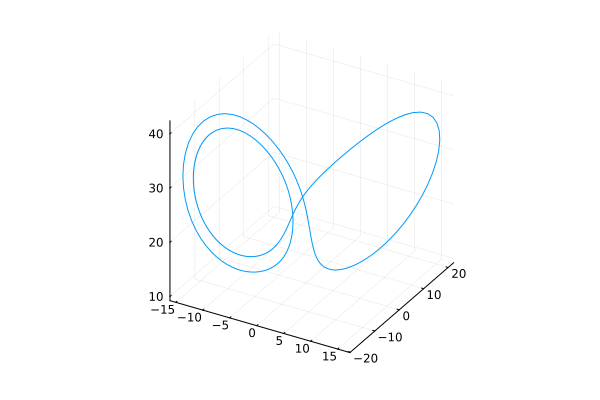

In [27]:
# let's see that periodic orbit
using Plots
# constants of the Lorenz system
σ, ρ, β = 10, 28, 8/3
# the right-hand side function
F(t, Y) = [σ*(Y[2]-Y[1]); Y[1]*(ρ-Y[3])-Y[2]; Y[1]*Y[2]-β*Y[3]]
_, Y = rk4(F, [X[1]; sqrt(β*(ρ-1)); X[2]], (0, 3), 0.01)
plot([Tuple(y) for y in Y]; label = false)

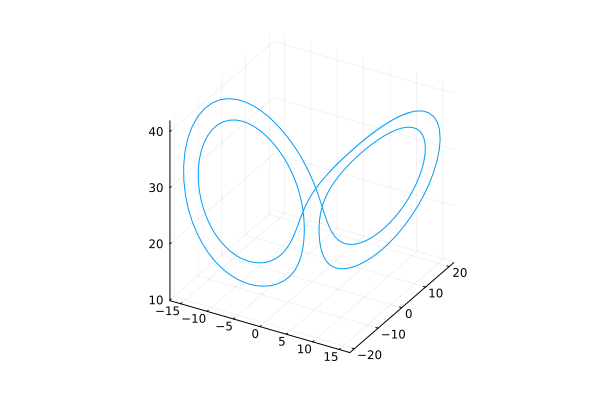

In [28]:
# let's try and find another periodic orbit
### YOUR CODE HERE
# let's try and find a periodic orbit which is periodic after a second return
G(X) = poincare(X; retn = 2) - X 
JG(X) = ForwardDiff.jacobian(G, X) 
X, n = newton(G, JG, [16.; 40.]; tol = 1e-12)
_, Y = rk4(F, [X[1]; sqrt(β*(ρ-1)); X[2]], (0, 3.2), 0.01)
plot([Tuple(y) for y in Y]; label = false)

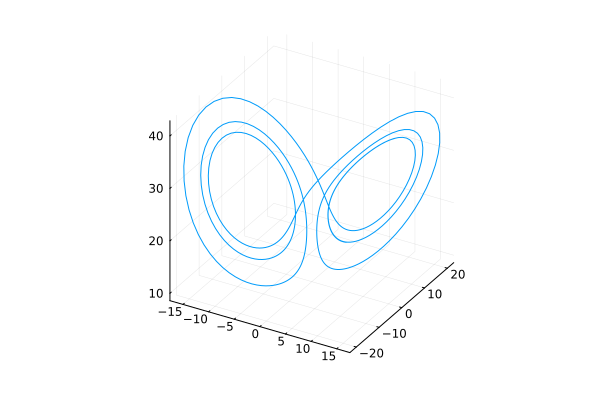

In [22]:
# ... third return ?
G(X) = poincare(X; retn = 3) - X 
JG(X) = ForwardDiff.jacobian(G, X) 
X, n = newton(G, JG, [16.; 35.]; tol = 1e-12)
_, Y = rk4(F, [X[1]; sqrt(β*(ρ-1)); X[2]], (0, 5), 0.01)
plot([Tuple(y) for y in Y]; label = false)